# **EXPLORATORY DATA ANALYSIS FOR COMPAS DATASET**





This document performs an Exploratory Data Analysis (EDA) on the COMPAS dataset, aiming to examine the variable's distributions, identify patterns and detect potential anomalies. Additionally, it checks key assumptions for predictive modeling, including linearity, monotonicity, feature interactions and multicollinearity to guide the selection of the most appropriate model.

## INITIAL DATASET EXPLORATION

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import matplotlib

In [7]:
COMPASdata = pd.read_csv("/content/cox-violent-parsed_filt.csv")
print(f'The dimension of the dataset is : {COMPASdata.shape}')
COMPASdata.count()

The dimension of the dataset is : (18316, 40)


,0
id,11001
name,18316
first,18316
last,18316
sex,18316
dob,18316
age,18316
age_cat,18316
race,18316
juv_fel_count,18316


In [8]:
COMPASdata = COMPASdata.drop_duplicates(subset=['name']) # Removal of duplicates
print(f'The dimension of the dataset is : {COMPASdata.shape}')
COMPASdata.count()

The dimension of the dataset is : (10855, 40)


,0
id,6560
name,10855
first,10855
last,10855
sex,10855
dob,10855
age,10855
age_cat,10855
race,10855
juv_fel_count,10855


## SELECTION AND DESCRIPTION OF FINAL VARIABLES

In [9]:
features = [
    'sex',
    'age',
    'race',
    'juv_fel_count',
    'juv_misd_count',
    'juv_other_count',
    'priors_count',
    'c_charge_degree',
]
COMPASdata[features].count() # These are the features that we have selected for the prediction of recidivism

,0
sex,10855
age,10855
race,10855
juv_fel_count,10855
juv_misd_count,10855
juv_other_count,10855
priors_count,10855
c_charge_degree,10185


Let's take a look at the **categorical predictors**

In [10]:
COMPASdata[features].describe(exclude="number")

,sex,race,c_charge_degree
count,10855,10855,10185
unique,2,6,14
top,Male,African-American,(F3)
freq,8604,5356,5501


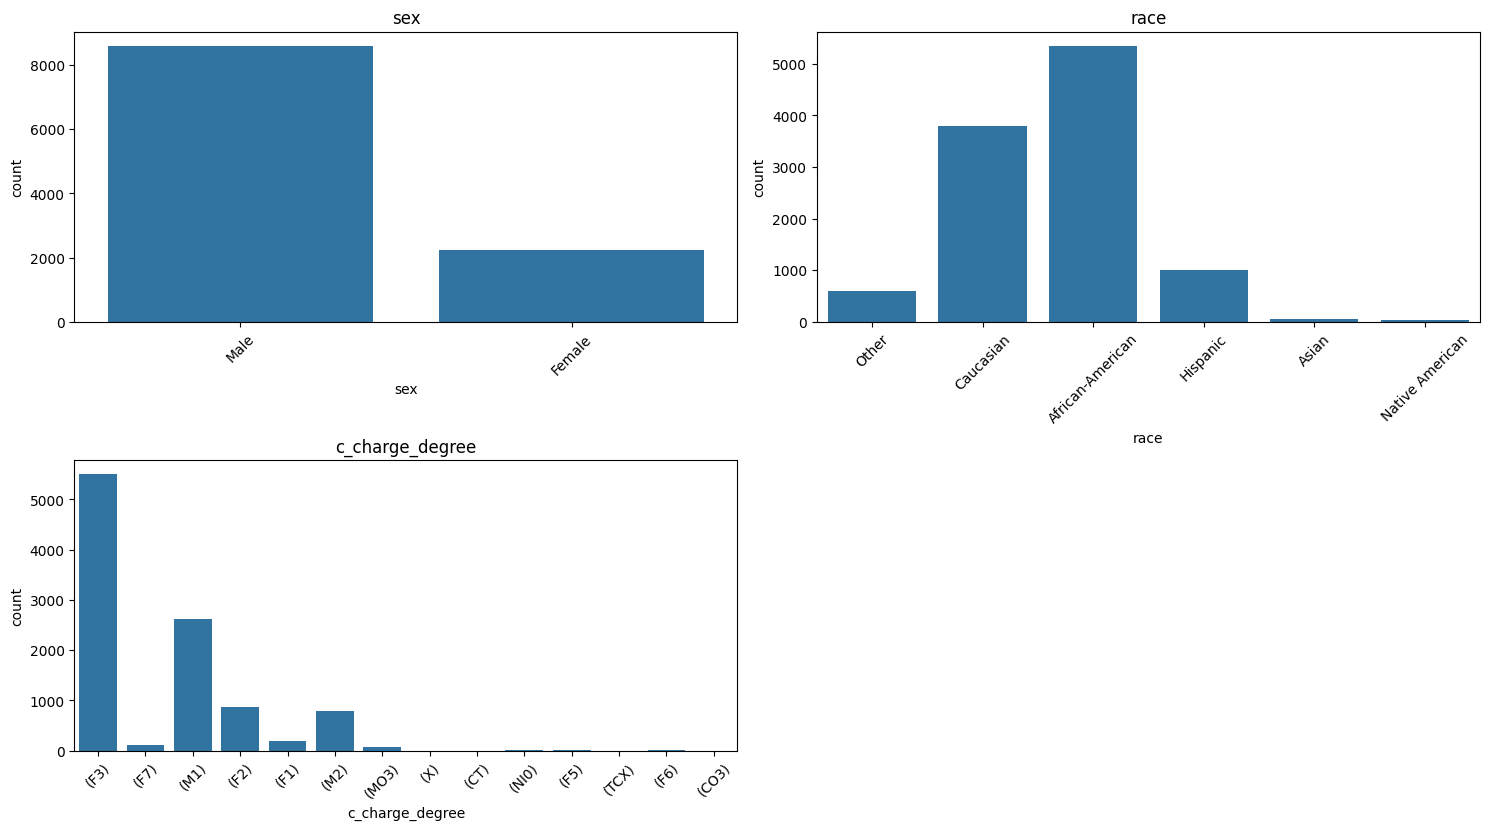

In [11]:
cat_features = COMPASdata[features].describe(exclude="number")
plt.figure(figsize=(15, 12))
for i, col in enumerate(cat_features):
    plt.subplot(3, 2, i+1)
    sns.countplot(x=col, data=COMPASdata)
    plt.title(col)
    plt.xticks(rotation=45)
    plt.tight_layout()

plt.show()

Meaning of charge degrees in Florida:
- F1 – First‑degree felony (most serious felony in this list).
- F2 – Second‑degree felony.
- F3 – Third‑degree felony.
- F5 – Fifth‑degree felony
- F6 – Sixth‑degree felony
- F7 – Seventh‑degree felony
- M1 – First‑degree misdemeanor (more serious misdemeanor).
- M2 – Second‑degree misdemeanor (less serious misdemeanor).
- TCX – Criminal traffic offense
- CO3 – County ordinance violation (third‑level county ordinance offense).
- MO3 – Municipal ordinance violation (third‑level city/municipal offense).
- ICT – Infraction / citation‑type offense (non‑criminal or low‑level offense).
- NI0 – Other infraction (miscellaneous non‑criminal or minor violation).
- X – Unknown / uncategorized charge degree

Reference: https://florida.public.law/statutes/fla._stat._775.081


Most of our **categorical features are imbalanced**. In the dataset most of the obervations are males, African-American and charged with Felony of degree 3

Now let's take a look at the **numerical predictors**

In [12]:
COMPASdata[features].select_dtypes(include='number').describe()

,age,juv_fel_count,juv_misd_count,juv_other_count,priors_count
count,10855.000000,10855.000000,10855.000000,10855.000000,10855.000000
mean,35.093413,0.059696,0.075173,0.094334,3.061170
std,12.015864,0.450346,0.451301,0.476208,4.650978
min,18.000000,0.000000,0.000000,0.000000,0.000000
25%,25.000000,0.000000,0.000000,0.000000,0.000000
50%,32.000000,0.000000,0.000000,0.000000,1.000000
75%,43.000000,0.000000,0.000000,0.000000,4.000000
max,96.000000,20.000000,13.000000,17.000000,43.000000


From the table we can see that there is a **significant presence of outliers**

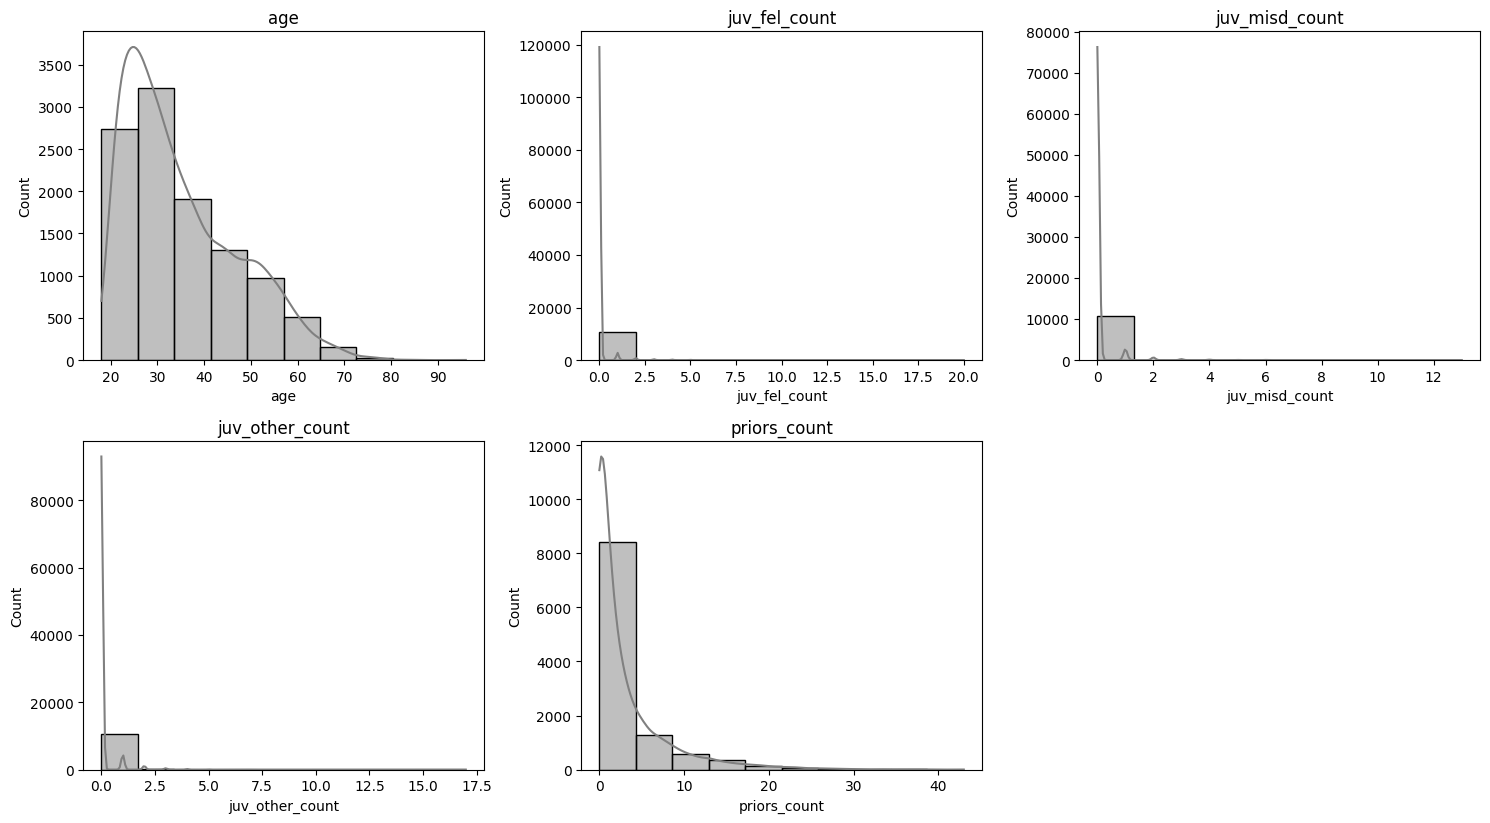

In [13]:
num_features = COMPASdata[features].select_dtypes(include='number')
bins = 10
plt.figure(figsize=(15, 12))

for i, col in enumerate(num_features):
    plt.subplot(3, 3, i+1)
    sns.histplot(COMPASdata[col], kde=True, bins=bins, color='grey', edgecolor='black')
    plt.title(col)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1434/3222812588.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(num_features, labels=num_features.columns, vert=True)


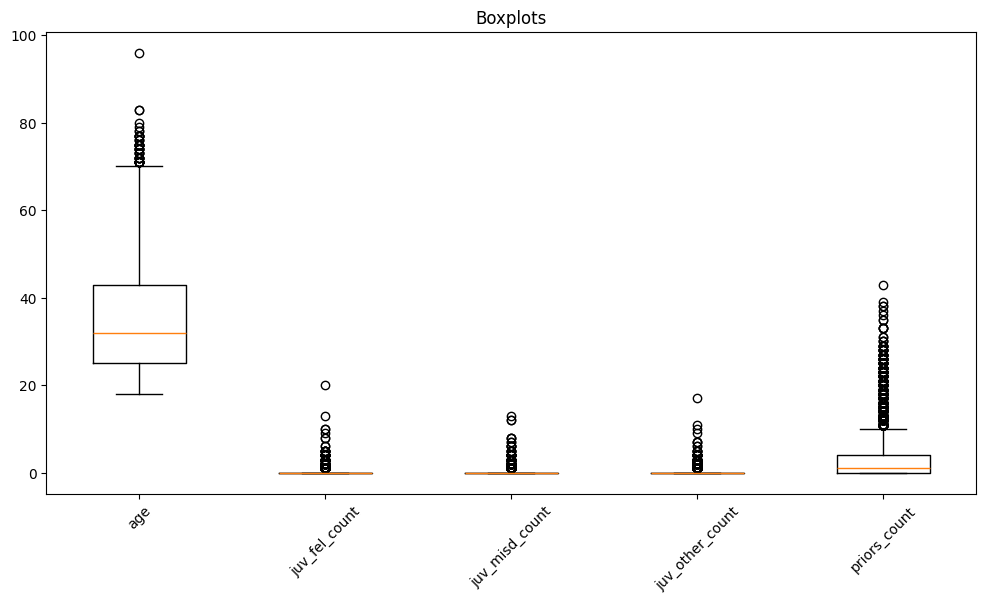

In [14]:
plt.figure(figsize=(12, 6))
plt.boxplot(num_features, labels=num_features.columns, vert=True)
plt.xticks(rotation=45)
plt.title('Boxplots')
plt.show()

## COMBINATIONS

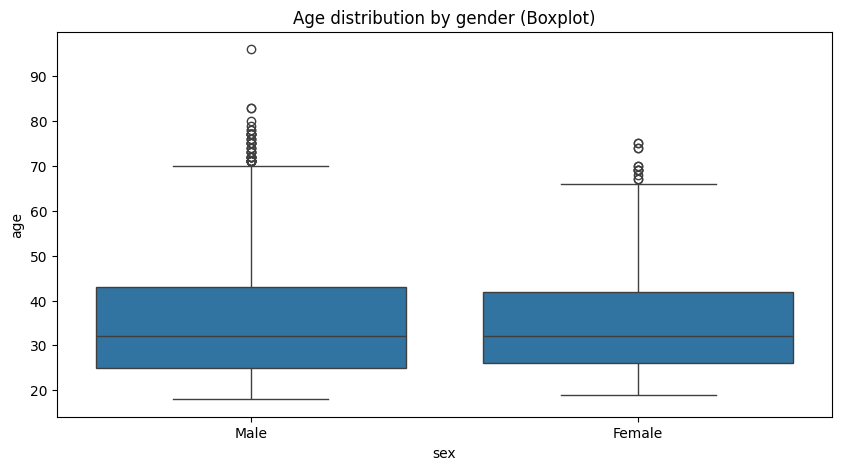

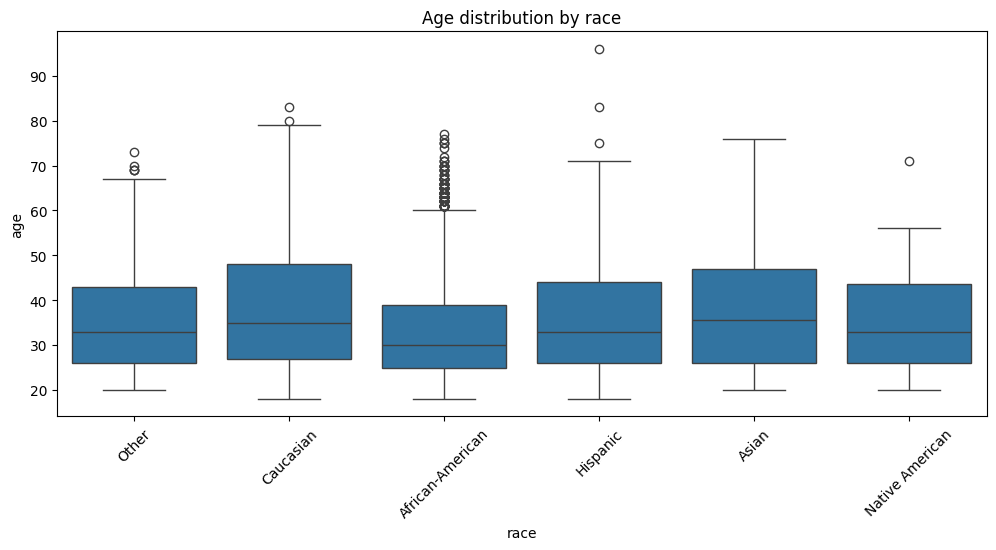

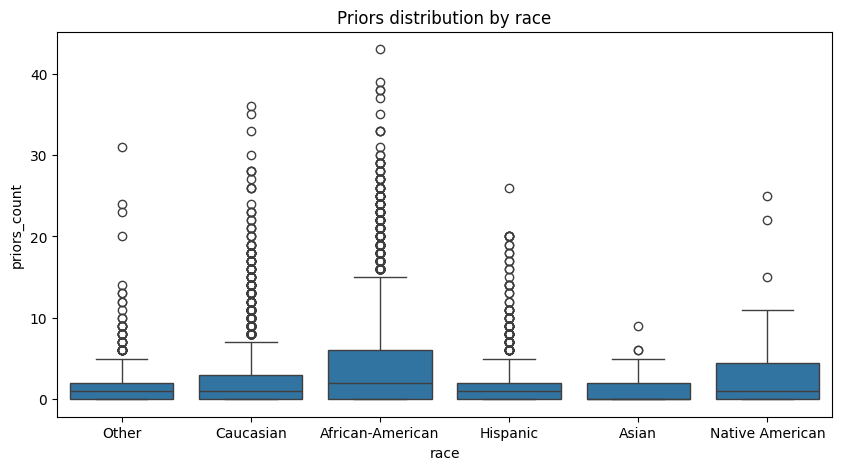

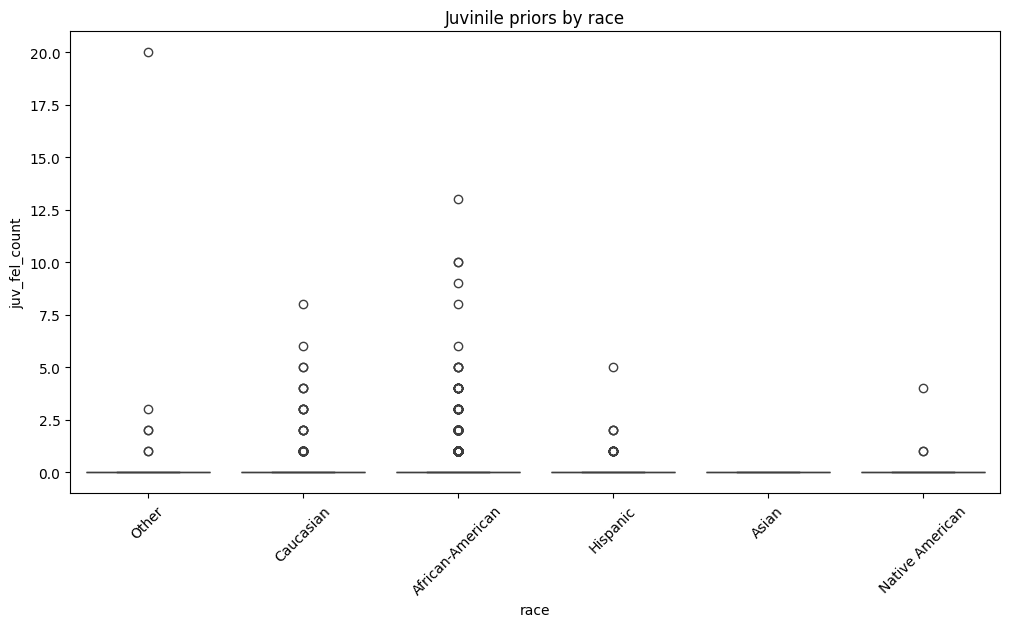

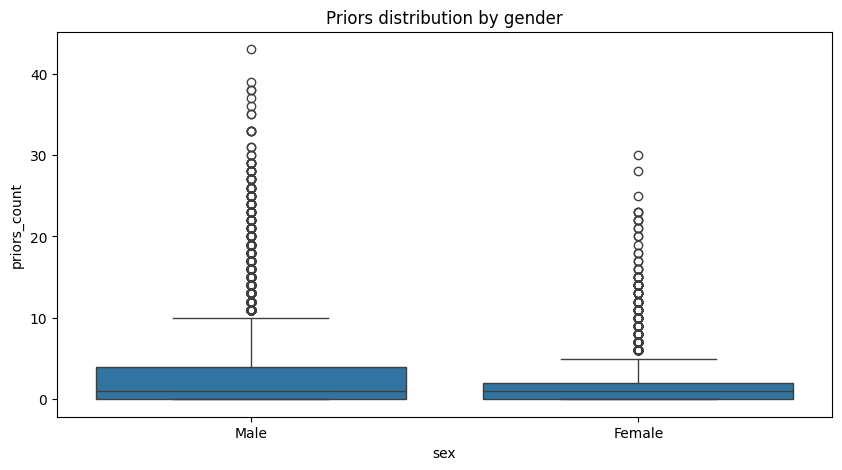

In [15]:
plt.figure(figsize=(10,5))
sns.boxplot(x="sex", y="age", data=COMPASdata)
plt.title("Age distribution by gender (Boxplot)")
plt.show()

plt.figure(figsize=(12,5))
sns.boxplot(x="race", y="age", data=COMPASdata)
plt.title("Age distribution by race")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x="race", y="priors_count", data=COMPASdata)
plt.title("Priors distribution by race")
plt.show()

plt.figure(figsize=(12,6))
sns.boxplot(x="race", y="juv_fel_count", data=COMPASdata)
plt.title("Juvinile priors by race")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x="sex", y="priors_count", data=COMPASdata)
plt.title("Priors distribution by gender")
plt.show()

Finally, let's check the **target feature** (real recidivism after 2 years)

In [16]:
target = COMPASdata['is_recid']

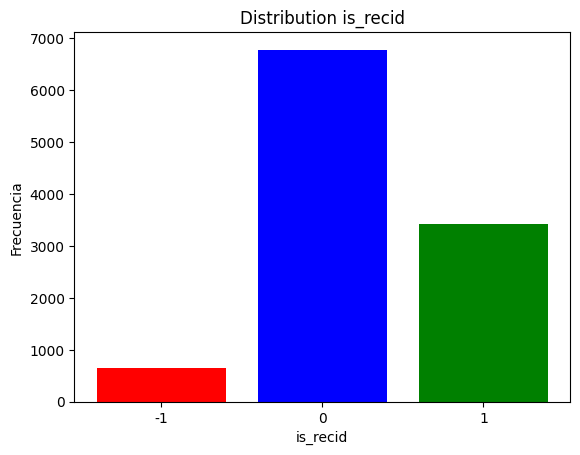

In [17]:
counts = COMPASdata['is_recid'].value_counts().sort_index()

plt.bar(counts.index.astype(str), counts.values, color=['red','blue','green'])
plt.xlabel('is_recid')
plt.ylabel('Frecuencia')
plt.title('Distribution is_recid')
plt.show()

From the chart we see that although the variable should be binary, a label -1 appears

In [21]:
COMPAS_filt = COMPASdata[COMPASdata["is_recid"] == -1] # Filter to see only the observations with is_recid = -1

In [22]:
COMPAS_filt[features].describe(exclude="number") # Categorical features filtered

,sex,race,c_charge_degree
count,648,648,1
unique,2,6,1
top,Male,African-American,(M1)
freq,506,278,1


In [23]:
COMPAS_filt[features].select_dtypes(include='number').describe() # Numerical features filtered

,age,juv_fel_count,juv_misd_count,juv_other_count,priors_count
count,648.000000,648.0,648.0,648.000000,648.0
mean,36.344136,0.0,0.0,0.009259,0.0
std,12.988061,0.0,0.0,0.110810,0.0
min,18.000000,0.0,0.0,0.000000,0.0
25%,25.000000,0.0,0.0,0.000000,0.0
50%,33.000000,0.0,0.0,0.000000,0.0
75%,45.250000,0.0,0.0,0.000000,0.0
max,78.000000,0.0,0.0,2.000000,0.0


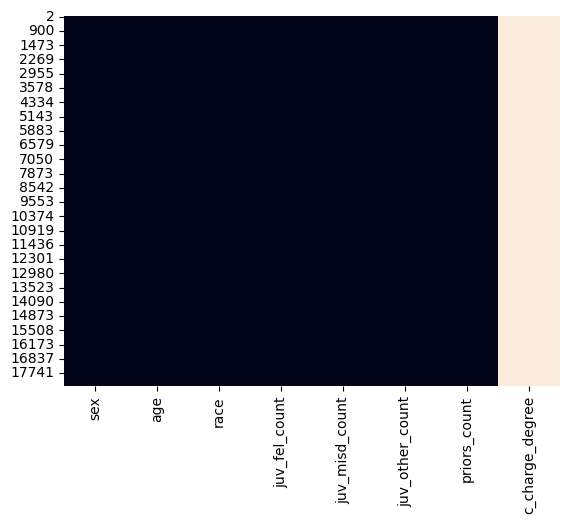

In [24]:
cmap = sns.mpl_palette("Set2", 2) # Presence of missing data in the filtered set
sns.heatmap(COMPAS_filt[features].isna(),cbar = False)
plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)

legend_handles = [Patch(color=cmap[True], label='NAN'),
                  Patch(color=cmap[False], label='Not NAN')]

Since we cannot draw a conclusion from the label being -1 (if it's recidivism or not) and the charge degrees are missing we **decided to drop the observations with label -1**.

In [25]:
COMPASdata = COMPASdata[COMPASdata["is_recid"] != -1]

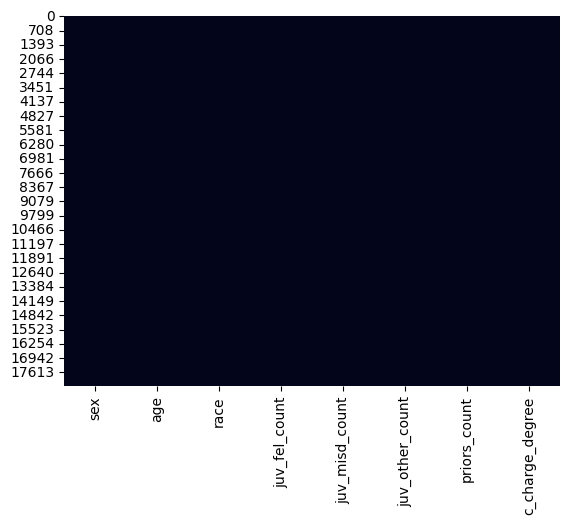

In [26]:
cmap = sns.mpl_palette("Set2", 2)
sns.heatmap(COMPASdata[features].isna(),cbar = False)
plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)

legend_handles = [Patch(color=cmap[True], label='NAN'),  # red
                  Patch(color=cmap[False], label='Not NAN')]

## ASSUMPTIONS

LINEARITY AND MONOTONICITY

In [27]:
COMPASdata[features].select_dtypes(include='number').describe()

,age,juv_fel_count,juv_misd_count,juv_other_count,priors_count
count,10207.00000,10207.000000,10207.000000,10207.000000,10207.000000
mean,35.01401,0.063486,0.079945,0.099735,3.255511
std,11.94774,0.464164,0.464997,0.489801,4.729936
min,18.00000,0.000000,0.000000,0.000000,0.000000
25%,25.00000,0.000000,0.000000,0.000000,0.000000
50%,32.00000,0.000000,0.000000,0.000000,1.000000
75%,43.00000,0.000000,0.000000,0.000000,4.000000
max,96.00000,20.000000,13.000000,17.000000,43.000000


/tmp/ipykernel_1434/1064418137.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_data = COMPASdata.groupby(temp_bins)['is_recid'].mean().reset_index()
/tmp/ipykernel_1434/1064418137.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_data = COMPASdata.groupby(temp_bins)['is_recid'].mean().reset_index()
/tmp/ipykernel_1434/1064418137.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_data = COMP

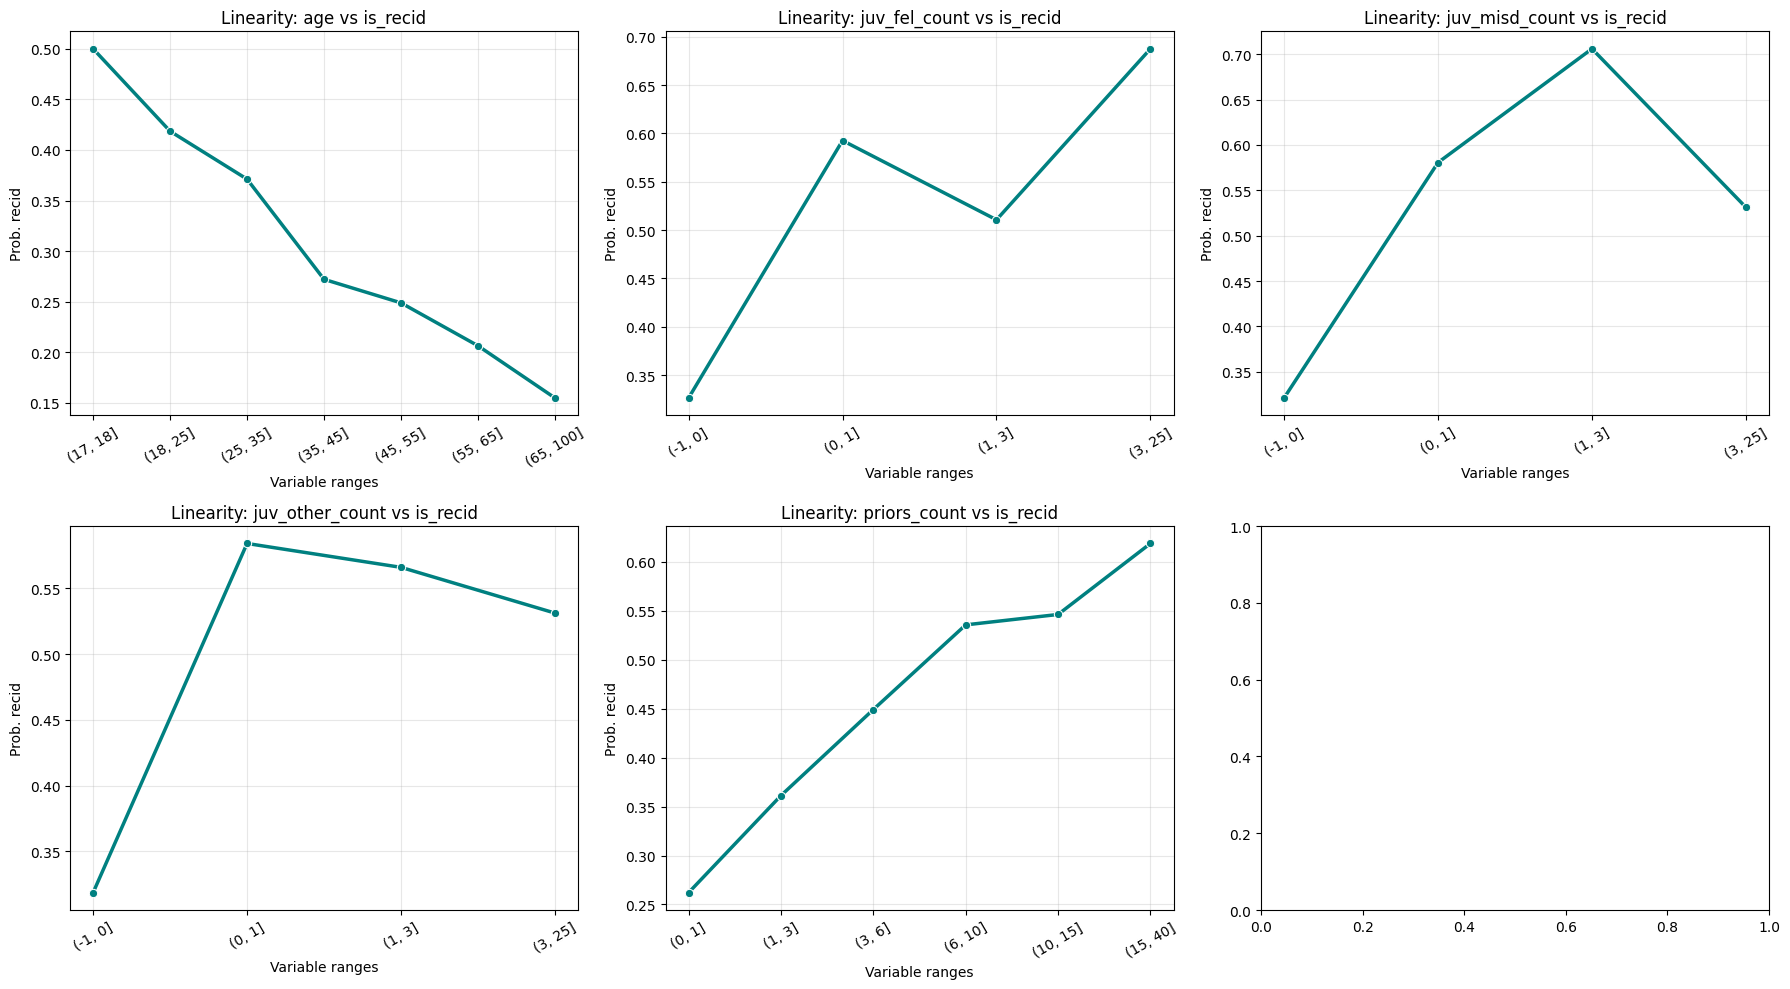

In [28]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(num_features):
    if col == 'age':
        bins = [17, 18, 25, 35, 45, 55, 65, 100]
    elif col == 'priors_count':
        bins = [0, 1, 3, 6, 10, 15, 40]
    elif 'juv' in col:
        bins = [-1, 0, 1, 3, 25]
    else: # c_days_from_compas
        bins = [-1, 0, 1, 2, 5, 10, 31]

    temp_bins = pd.cut(COMPASdata[col], bins=bins)
    binned_data = COMPASdata.groupby(temp_bins)['is_recid'].mean().reset_index()
    sns.lineplot(ax=axes[i], x=range(len(binned_data)), y=binned_data['is_recid'], marker="o", color='teal', linewidth=2.5)

    axes[i].set_xticks(range(len(binned_data)))
    axes[i].set_xticklabels(binned_data[col].astype(str), rotation=30)
    axes[i].set_title(f'Linearity: {col} vs is_recid')
    axes[i].set_ylabel('Prob. recid')
    axes[i].set_xlabel('Variable ranges')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



FEATURE INTERACTION

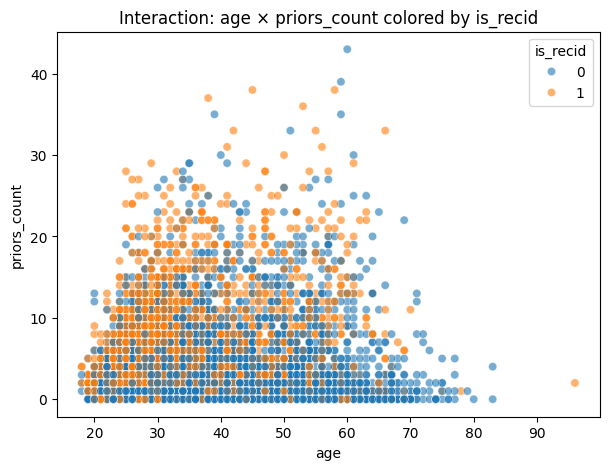

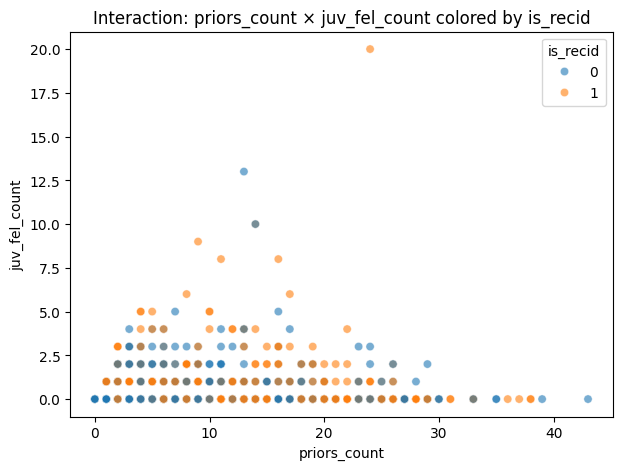

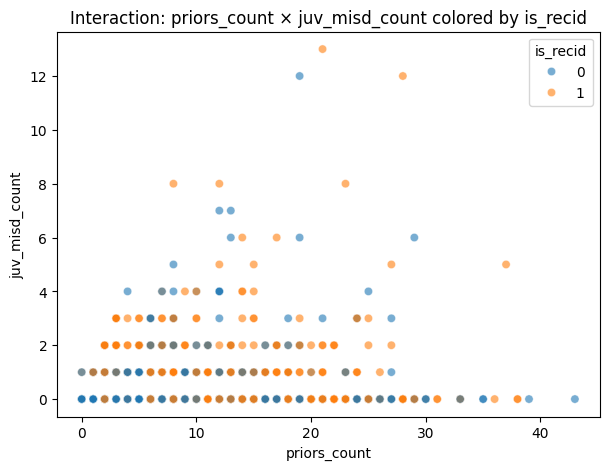

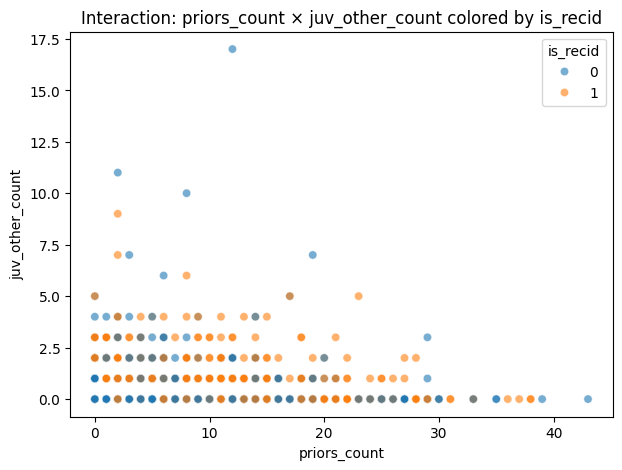

In [34]:
num_interactions = [ # interctions with numerical variables
    ('age', 'priors_count'),
    ('priors_count', 'juv_fel_count'),
    ('priors_count', 'juv_misd_count'),
    ('priors_count', 'juv_other_count')
]

for x, y in num_interactions:
    plt.figure(figsize=(7,5))
    sns.scatterplot(x=COMPASdata[x], y=COMPASdata[y], hue=COMPASdata['is_recid'], alpha=0.6)
    plt.title(f'Interaction: {x} × {y} colored by is_recid')
    plt.show() # Numerical interactions

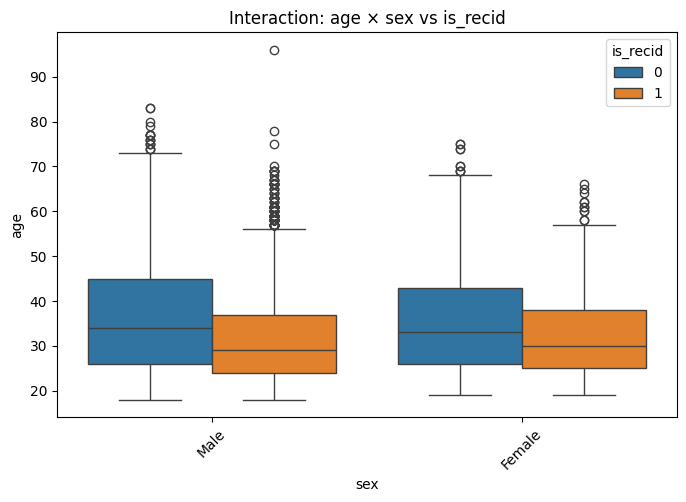

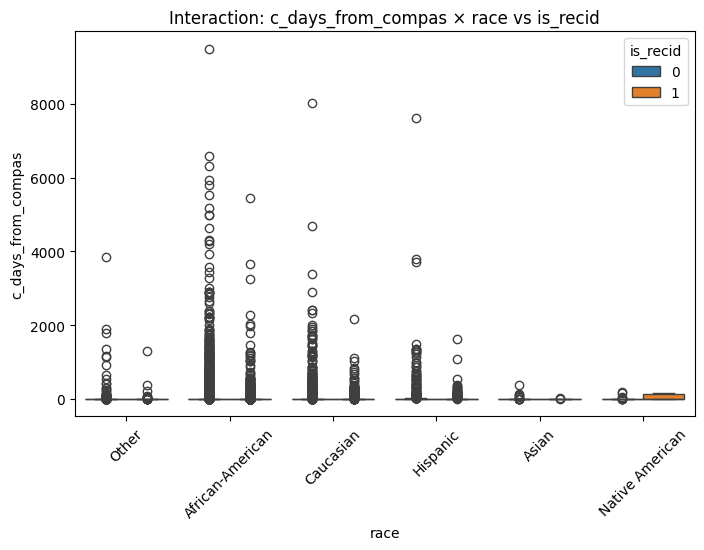

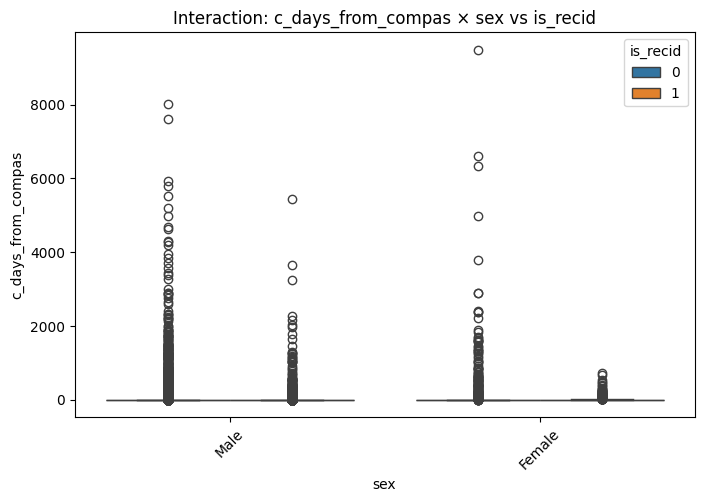

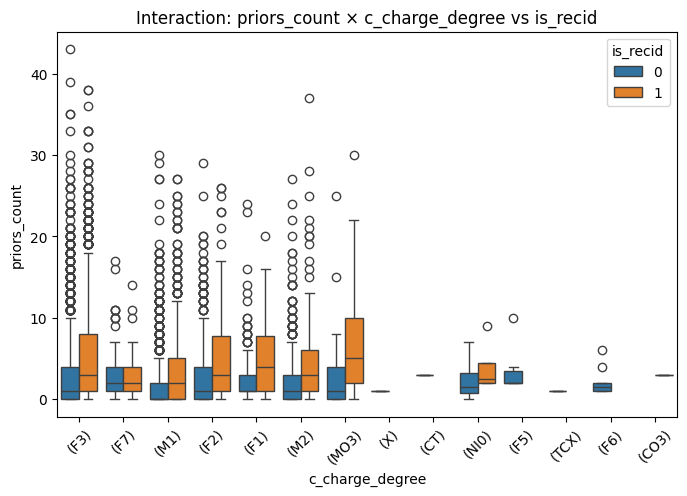

In [35]:
num_cat_interactions = [ # numerical and categorical interactions
    ('age', 'sex'),
    ('c_days_from_compas', 'race'),
    ('c_days_from_compas', 'sex'),
    ('priors_count', 'c_charge_degree')
]

for num, cat in num_cat_interactions:
    plt.figure(figsize=(8,5))
    sns.boxplot(x=COMPASdata[cat], y=COMPASdata[num], hue=COMPASdata['is_recid'])
    plt.title(f'Interaction: {num} × {cat} vs is_recid')
    plt.xticks(rotation=45)
    plt.show() # Numerical vs categorical interactions


Interaction: sex × c_charge_degree (normalized frequencies)
 is_recid                       0         1
sex    c_charge_degree                    
Female (F1)             0.893617  0.106383
       (F2)             0.769231  0.230769
       (F3)             0.702392  0.297608
       (F6)             1.000000  0.000000
       (F7)             0.733333  0.266667
       (M1)             0.814353  0.185647
       (M2)             0.757396  0.242604
       (MO3)            0.785714  0.214286
Male   (CO3)            0.000000  1.000000
       (CT)             1.000000  0.000000
       (F1)             0.777027  0.222973
       (F2)             0.635714  0.364286
       (F3)             0.613330  0.386670
       (F5)             1.000000  0.000000
       (F6)             1.000000  0.000000
       (F7)             0.730769  0.269231
       (M1)             0.691371  0.308629
       (M2)             0.657980  0.342020
       (MO3)            0.656250  0.343750
       (NI0)            0.500000  0

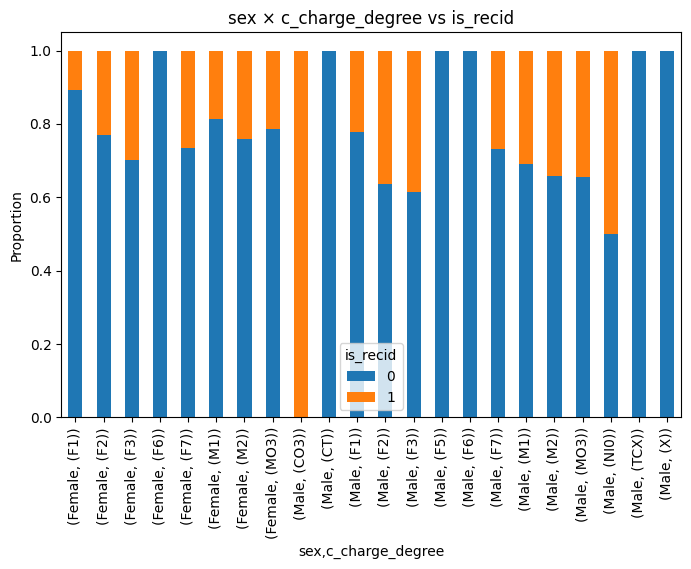


Interaction: race × c_charge_degree (normalized frequencies)
 is_recid                                 0         1
race             c_charge_degree                    
African-American (CO3)            0.000000  1.000000
                 (F1)             0.743119  0.256881
                 (F2)             0.598848  0.401152
                 (F3)             0.583275  0.416725
                 (F5)             1.000000  0.000000
                 (F6)             1.000000  0.000000
                 (F7)             0.725806  0.274194
                 (M1)             0.641667  0.358333
                 (M2)             0.605479  0.394521
                 (MO3)            0.673913  0.326087
                 (NI0)            0.750000  0.250000
Asian            (F1)             1.000000  0.000000
                 (F2)             0.750000  0.250000
                 (F3)             0.653846  0.346154
                 (M1)             0.944444  0.055556
                 (M2)             1.

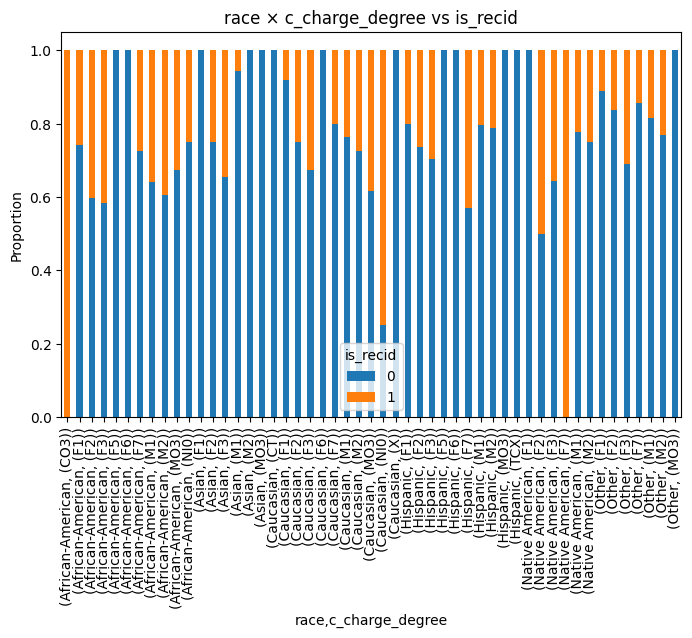

In [37]:
cat_interactions = [ # categorical interactions
    ('sex', 'c_charge_degree'),
    ('race', 'c_charge_degree')
]

for cat1, cat2 in cat_interactions:
    cross = pd.crosstab([COMPASdata[cat1], COMPASdata[cat2]], COMPASdata['is_recid'], normalize='index')
    print(f'\nInteraction: {cat1} × {cat2} (normalized frequencies)\n', cross)

    cross.plot(kind='bar', stacked=True, figsize=(8,5))
    plt.title(f'{cat1} × {cat2} vs is_recid')
    plt.ylabel('Proportion')
    plt.show() # Categorical interactions

MULTICOLLINEARITY

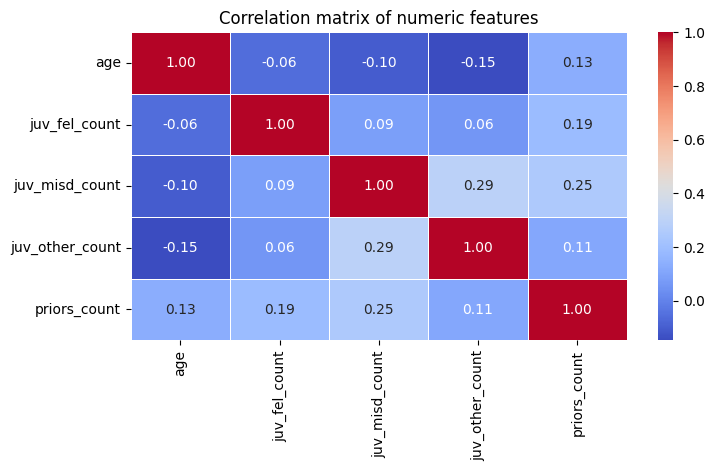

In [38]:
plt.figure(figsize=(8, 4))
corr_matrix = num_features.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation matrix of numeric features')
plt.show()